In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/dhruvildave/en-fr-translation-dataset/en-fr.csv
/kaggle/input/datasets/devicharith/language-translation-englishfrench/eng_-french.csv


In [83]:
import torch
import matplotlib.pyplot as plt
import random
import math
import torch.nn.functional as F
import torch.nn as nn

In [84]:
lines = open('/kaggle/input/datasets/devicharith/language-translation-englishfrench/eng_-french.csv', 'r',  encoding='utf-8').read().splitlines()
len(lines)

175622

In [85]:
lines = [line.replace('\u202f', ' ') for line in lines]

data = [(line.split(',')) for line in lines]
# data[:10]

data = data[1:]

data[:10]



[['Hi.', 'Salut!'],
 ['Run!', 'Cours !'],
 ['Run!', 'Courez !'],
 ['Who?', 'Qui ?'],
 ['Wow!', 'Ça alors !'],
 ['Fire!', 'Au feu !'],
 ['Help!', "À l'aide !"],
 ['Jump.', 'Saute.'],
 ['Stop!', 'Ça suffit !'],
 ['Stop!', 'Stop !']]

In [86]:
X = [d[0] for d in data]
Y = [d[1] for d in data]




In [ ]:
rnn = nn.RNN(10, 20, 2)
input = torch.randn(5, 3, 10)
h0 = torch.randn(2, 3, 20)
output, hn = rnn(input, h0)
output

In [87]:
import re

special_tokens = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]

src_word2idx = {}
src_idx2word = {}

tgt_word2idx = {}
tgt_idx2word = {}


# initialize special tokens
for idx, token in enumerate(special_tokens):

    src_word2idx[token] = idx
    src_idx2word[idx] = token

    tgt_word2idx[token] = idx
    tgt_idx2word[idx] = token


def tokenize(sentence):

    sentence = sentence.lower().strip()

    # split punctuation into separate tokens
    tokens = re.findall(r"\w+(?:'\w+)*|[^\w\s]", sentence)

    return tokens


# build english vocab
current_idx = len(special_tokens)

for sentence in X:

    tokens = tokenize(sentence)

    for token in tokens:

        if token not in src_word2idx:

            src_word2idx[token] = current_idx
            src_idx2word[current_idx] = token

            current_idx += 1


# build french vocab
current_idx = len(special_tokens)

for sentence in Y:

    tokens = tokenize(sentence)

    for token in tokens:

        if token not in tgt_word2idx:

            tgt_word2idx[token] = current_idx
            tgt_idx2word[current_idx] = token

            current_idx += 1

In [7]:
print(len(src_word2idx))
list(tgt_word2idx.keys())[:20]

14221


['<PAD>',
 '<SOS>',
 '<EOS>',
 '<UNK>',
 'salut',
 '!',
 'cours',
 'courez',
 'qui',
 '?',
 'ça',
 'alors',
 'au',
 'feu',
 'à',
 "l'aide",
 'saute',
 '.',
 'suffit',
 'stop']

In [88]:
class RNNCell(nn.Module):

    def __init__(self, input_size, hidden_size):
        super().__init__()

        # bias = false
        self.hidden_size = hidden_size

        # we will initialise the weights of a single RNNCell
        # Wx and Wh - weights of the input and the hidden layer

        # assume, input_dim = 4, hidden = 5
        # input x_t at any time = (4, )
        # output has to be 5, so Wx has to be (5, 4)

        # h = (hidden_size, )
        # Wh must be (hidden_size, hidden_size)
        

        self.Wx = nn.Parameter(torch.randn(hidden_size, input_size))
        self.Wh = nn.Parameter(torch.randn(hidden_size, hidden_size))


    def forward(self, x_t, h_prev):

        if h_prev is None:
            h_prev = torch.zeros(self.Wh.shape[0], )

        h_t = torch.tanh(self.Wx @ x_t + self.Wh @ h_prev)
        return h_t

In [89]:
class RNN(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        num_layers = 1
    ):

        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.cells = nn.ModuleList(RNNCell(hidden_size, hidden_size) for _ in range(num_layers))
        # first layer alone has input x while all the others have output of prev layers
        self.cells[0] = RNNCell(input_size, hidden_size)


    def forward(
        self,
        x,
        h
    ):
        time_steps = x.shape[0] # x is of shape (time_steps, input_dims)
        
        outputs = []

        if h is None:
            h = torch.zeros(self.num_layers, self.hidden_size) # 3, 5

        
        for t in range(time_steps):

            x_t = x[t]
            h_t_1 = x_t
            
            for layer in range(self.num_layers):

                current_cell = self.cells[layer]

                # h_t_1 is of size (input_size, ) for the first layer
                # h_t_1 is of size (hidden, ) for subsequent layers
                # h_layer is of size (hidden_size, )
                
                h_t = current_cell(h_t_1, h[layer])
                # num_layers, hidden_size
                # so the input must be of size hidden
                h_t_1 = h_t
                h[layer] = h_t
                

            outputs.append(h_t)

        return {"outputs": torch.stack(outputs), "final_hidden_state": h} # array of h across all timestamps               
                

        
        
        

In [90]:
"""
Update gate:
z_t = σ(W_z x_t + U_z h_(t-1))

Reset gate:
r_t = σ(W_r x_t + U_r h_(t-1))

Candidate hidden state:
h~_t = tanh(W_h x_t + U_h (r_t ⊙ h_(t-1)))

Final hidden state:
h_t = (1 - z_t) ⊙ h_(t-1) + z_t ⊙ h~_t
"""

# We are implementing the GRU Cell here

class GRUCell(nn.Module):

    def __init__(self, batch_size, input_size, hidden_size):
        super().__init__()

        # bias = false
        self.hidden_size = hidden_size
        self.input_size = input_size

        """

            The grucell will take the following as input: x_t and h_t-1 
            we need the following 6 weights W_z, Uz, Wr, Ur, Wh, Uh 
            
            dimensions:
                x_t is going to be (input_dim, 1) 
                h_t-1 is going to be (hidden, 1) 
            
            so Wz should be (hiddenxinput_dim) 
            Uz sohuld be (hiddenxhidden)
            Wr should be same as Wz and 
            Ur same as Uz 
            same for Wh as well
            
        """
        

        self.Wz = nn.Parameter(torch.randn(hidden_size, input_size))
        self.Uz = nn.Parameter(torch.randn(hidden_size, hidden_size))

        self.Wr = nn.Parameter(torch.randn(hidden_size, input_size))
        self.Ur = nn.Parameter(torch.randn(hidden_size, hidden_size))

        self.Wh = nn.Parameter(torch.randn(hidden_size, input_size))
        self.Uh = nn.Parameter(torch.randn(hidden_size, hidden_size))


    def forward(self, x_t, h_prev):

        if h_prev is None:
            h_prev = torch.zeros((x_t.shape[0], self.hidden_size))

        """
            Update gate:
            z_t = σ(W_z x_t + U_z h_(t-1))
            
            Reset gate:
            r_t = σ(W_r x_t + U_r h_(t-1))
            
            Candidate hidden state:
            h~_t = tanh(W_h x_t + U_h (r_t ⊙ h_(t-1)))
            
            Final hidden state:
            h_t = (1 - z_t) ⊙ h_(t-1) + z_t ⊙ h~_t
        """


        # xt is of size (batch, input)
        # Wz is (hidden, input)
        z_t = torch.sigmoid(x_t @ self.Wz.T + h_prev @ self.Uz.T)
        r_t = torch.sigmoid(x_t @ self.Wr.T + h_prev @ self.Ur.T)
        h_candidate_t = torch.tanh(x_t @ self.Wh.T + (r_t * h_prev) @ self.Uh.T)
        h_t = (torch.ones(z_t.shape) - z_t) * h_prev + z_t * h_candidate_t

        return h_t


In [91]:
input = torch.randn(2)
torch.sigmoid(input)


tensor([0.3523, 0.3717])

In [92]:
class GRU(nn.Module):

    def __init__(
        self,
        batch_size,
        input_size,
        hidden_size,
        num_layers = 1
    ):

        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.cells = nn.ModuleList(GRUCell(batch_size, hidden_size, hidden_size) for _ in range(num_layers))
        # first layer alone has input x while all the others have output of prev layers
        self.cells[0] = GRUCell(batch_size, input_size, hidden_size)


    def forward(
        self,
        x,
        h = None
    ):
        # x is of shape (batch_size, time_steps, input_dims)
        
        time_steps = x.shape[1] 
        
        outputs = []

        if h is None:
            h = torch.zeros(self.num_layers, x.shape[0], self.hidden_size)

        
        for t in range(time_steps):

            x_t = x[:, t, :]
            h_t_1 = x_t
            new_hidden_states = []
            
            for layer in range(self.num_layers):

                current_cell = self.cells[layer]

                # h_t_1 is of size (input_size, ) for the first layer
                # h_t_1 is of size (hidden, ) for subsequent layers
                # h_layer is of size (hidden_size, )
                
                h_t = current_cell(h_t_1, h[layer])
                # num_layers, hidden_size
                # so the input must be of size hidden
                h_t_1 = h_t
                new_hidden_states.append(h_t)

            h = torch.stack(new_hidden_states)
            outputs.append(h_t)

        return {"outputs": torch.stack(outputs), "final_hidden_state": h} # array of h across all timestamps               
                

        
        
        

In [93]:
class Encoder(nn.Module):

    def __init__(
        self,
        batch_size,
        vocab_size,
        embedding_dim,
        hidden_size,
        num_layers = 1
            ):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.gru = GRU(
            batch_size=batch_size,
            input_size=embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers
        )

    

    def forward(self, x):
        embedded = self.embedding(x)

        outputs = self.gru(embedded)
        return outputs

In [94]:
X[111450], Y[111450]
print(len(src_word2idx))
print(len(tgt_idx2word))

print(X[100].split(" "))

14221
28671
['Come', 'in.']


In [95]:
class BahdanauAttention(nn.Module):
    
    def __init__(self, hidden_size):
        super().__init__()
        self.Wh = nn.Parameter(torch.randn(hidden_size, hidden_size))
        self.Ws = nn.Parameter(torch.randn(hidden_size, hidden_size))
        self.v = nn.Parameter(torch.randn(hidden_size, ))

    def forward(self, decoder_hidden, encoder_outputs):

        # decoder_hidden - (batch_size, hidden_size)
        # encoder output - (time, batch, hidden)

        # one scalar per time per batch
        # (time, batch)
        alignments = []

        for encoder_op in encoder_outputs:
            tanh = torch.tanh(encoder_op @ self.Wh.T + decoder_hidden @ self.Ws.T)
            # tanh now has (batch, hidden)
            e_t_i = tanh @ self.v
            # eti shape = (batch, hidden) x (hidden, ) = (batch, )
            alignments.append(e_t_i)


        alignments = torch.stack(alignments) # shape (time, batch)
        attention_weights = alignments.softmax(dim=0) # (batch, )
        attention_weights = attention_weights.view(alignments.shape[0], alignments.shape[1], 1)

        context_vector = torch.sum(attention_weights * encoder_outputs, dim=0)
        # (time, batch, 1) * (time, batch, hidden) -> broadcast over all neurons

        return {"context": context_vector, "attention_weights": attention_weights}

        
        
        
            

In [100]:
class Decoder(nn.Module):

    def __init__(
        self,
        batch_size,
        vocab_size,
        embedding_dim,
        hidden_size,
        num_layers=1
    ):

        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.attention = BahdanauAttention(hidden_size)

        self.gru = GRU(
            batch_size = batch_size,
            input_size=embedding_dim + hidden_size,
            hidden_size = hidden_size,
            num_layers = num_layers
        )

        self.output_layer = nn.Linear(hidden_size, vocab_size)
        

    def forward(self, encoded_outputs, decoder_prev_hidden, prev_output):
        s_t_1 = decoder_prev_hidden
        h = encoded_outputs
        y_t_1 = prev_output

         # decoder_prev_hidden - (batch_size, hidden_size)
        # encoder output - (time, batch, hidden)

        # we need the previous output as part of the current input
        x_t = self.embedding(y_t_1) # -> shape (batch, embedded_dim)

        # bahdanau attention takes encoded_outputs, decoder_prev_hidden
        # this returns context vector and attention vector

        attention_output = self.attention(decoder_prev_hidden[-1], encoded_outputs)

        attention_wts = attention_output.get("attention_weights")
        context_vector = attention_output.get("context")
        # C = (batch, hidden)

        combined_input = torch.cat((x_t, context_vector), dim=1)
        combined_input = combined_input.view(-1, 1, combined_input.shape[1])
        # (batch_size, 1, (input dims + hidden size))

        decoder_gru_op = self.gru(combined_input, decoder_prev_hidden)
        
        op = decoder_gru_op.get("outputs")
        decoder_final_hidden = decoder_gru_op.get("final_hidden_state")

        # op - (1, batch, hidden)
        op = op.squeeze(0)

        logits = self.output_layer(op)

        return (logits, decoder_final_hidden, attention_wts)

        
        
        

        
            


In [97]:
attention_wts_collected = []

In [101]:
class Seq2Seq(nn.Module):

    def __init__(self, encoder, decoder,tgt_word2idx):

        super().__init__()

        self.encoder = encoder
        self.decoder = decoder

        self.sos_token = tgt_word2idx["<SOS>"]
        self.eos_token = tgt_word2idx["<EOS>"]


    def forward( self, src, tgt):

        """
        src:
            (batch, src_time)

        tgt:
            (batch, tgt_time)
        """

        # encoding
        
        encoder_op = self.encoder(src)

        encoder_outputs = encoder_op["outputs"]

        encoder_hidden = encoder_op["final_hidden_state"]

        #decoding
        decoder_hidden = encoder_hidden
        # one SOS token per batch item
        prev_output = torch.full((src.shape[0],), self.sos_token, dtype=torch.long)


        outputs = []
        attention_wts_collected = []


        # iterate over target timesteps
        for t in range(tgt.shape[1]):

            decoder_op = self.decoder(
                encoder_outputs,
                decoder_hidden,
                prev_output
            )

            logits, decoder_hidden, attention_wts = decoder_op


            # logits:
            # (batch, vocab_size)

            outputs.append(logits)

            attention_wts_collected.append(
                attention_wts
            )


            # teacher forcing
            prev_output = tgt[:, t]


        outputs = torch.stack(outputs)

        return {
            "logits": outputs,
            "attention_weights": attention_wts_collected
        }

In [102]:
encoder = Encoder(
    batch_size=32,
    vocab_size=len(src_word2idx),
    embedding_dim=4,
    hidden_size=32,
    num_layers=2
)

decoder = Decoder(
    batch_size=32,
    vocab_size=len(tgt_word2idx),
    embedding_dim=4,
    hidden_size=32,
    num_layers=2
)

model = Seq2Seq(
    encoder,
    decoder,
    tgt_word2idx
)

In [103]:
def create_batch(src_sentences, tgt_sentences, src_word2idx, tgt_word2idx):

    """
    Returns:

    src_batch:
        (batch, src_time)

    tgt_batch:
        (batch, tgt_time)
    """

    src_tokenized = [ tokenize(sentence) for sentence in src_sentences]

    tgt_tokenized = [["<SOS>"] + tokenize(sentence) + ["<EOS>"] for sentence in tgt_sentences]


    # associate with token IDs
    src_ids = [[src_word2idx.get(token, src_word2idx["<UNK>"]) for token in sentence]
        for sentence in src_tokenized
    ]

    tgt_ids = [
        [
            tgt_word2idx.get(token, tgt_word2idx["<UNK>"]) for token in sentence
        ]
        for sentence in tgt_tokenized
    ]


    # PAD 

    src_max_len = max(len(sentence) for sentence in src_ids)
    tgt_max_len = max(len(sentence) for sentence in tgt_ids)

    src_padded = [
        sentence + [src_word2idx["<PAD>"]] * (src_max_len - len(sentence))
        for sentence in src_ids
    ]

    tgt_padded = [
        sentence + [tgt_word2idx["<PAD>"]] * (tgt_max_len - len(sentence))
        for sentence in tgt_ids
    ]


    # ---------------- TENSORS ----------------

    src_batch = torch.tensor(src_padded, dtype=torch.long)
    tgt_batch = torch.tensor(tgt_padded, dtype=torch.long)

    return src_batch, tgt_batch

In [104]:
epoch_losses = []

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

loss_function = nn.CrossEntropyLoss(ignore_index=tgt_word2idx["<PAD>"])

num_epochs = 100
batch_size = 32


for epoch in range(num_epochs):

    total_loss = 0

    for i in range(0, 100, batch_size):

        # create a batch
        
        src_batch_sentences = X[i:i+batch_size]
        tgt_batch_sentences = Y[i:i+batch_size]

        src_batch, tgt_batch = create_batch(src_batch_sentences, tgt_batch_sentences, src_word2idx, tgt_word2idx)


        # forward pass

        optimizer.zero_grad()

        model_op = model(src_batch, tgt_batch[:, :-1])

        logits = model_op["logits"]

        targets = tgt_batch[:, 1:]


        # logits:
        # (time, batch, vocab)

        # targets:
        # (batch, time)


        logits = logits.permute(1, 0, 2)
        logits = logits.reshape(-1, logits.shape[-1])
        targets = targets.reshape(-1)


        loss = loss_function(logits, targets)


        loss.backward()
        optimizer.step()
        total_loss += loss.item()


    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    epoch_losses.append(total_loss)

Epoch 1, Loss: 41.3188
Epoch 2, Loss: 41.0747
Epoch 3, Loss: 40.8280
Epoch 4, Loss: 40.6254
Epoch 5, Loss: 40.4419
Epoch 6, Loss: 40.1604
Epoch 7, Loss: 39.9711
Epoch 8, Loss: 39.7762
Epoch 9, Loss: 39.5694
Epoch 10, Loss: 39.4232
Epoch 11, Loss: 39.2227
Epoch 12, Loss: 39.0527
Epoch 13, Loss: 38.8330
Epoch 14, Loss: 38.6475
Epoch 15, Loss: 38.4422
Epoch 16, Loss: 38.1579
Epoch 17, Loss: 37.9305
Epoch 18, Loss: 37.6836
Epoch 19, Loss: 37.5280
Epoch 20, Loss: 37.2502
Epoch 21, Loss: 37.0036
Epoch 22, Loss: 36.8142
Epoch 23, Loss: 36.5634
Epoch 24, Loss: 36.2998
Epoch 25, Loss: 36.0346
Epoch 26, Loss: 35.9304
Epoch 27, Loss: 35.7366
Epoch 28, Loss: 35.5471
Epoch 29, Loss: 35.2434
Epoch 30, Loss: 35.0519
Epoch 31, Loss: 34.8022
Epoch 32, Loss: 34.5147
Epoch 33, Loss: 34.3011
Epoch 34, Loss: 34.1120
Epoch 35, Loss: 33.8478
Epoch 36, Loss: 33.5380
Epoch 37, Loss: 33.2270
Epoch 38, Loss: 32.9288
Epoch 39, Loss: 32.7254
Epoch 40, Loss: 32.4906
Epoch 41, Loss: 32.2511
Epoch 42, Loss: 32.0637
E

In [105]:
def translate(model, sentence, max_len=20):

    model.eval()

    src_tokens = tokenize(sentence)

    src_ids = torch.tensor([src_word2idx.get(token, src_word2idx["<UNK>"]) for token in src_tokens]).unsqueeze(0)

    encoder_op = model.encoder(src_ids)

    encoder_outputs = encoder_op["outputs"]

    decoder_hidden = encoder_op["final_hidden_state"]

    current_token = torch.tensor([tgt_word2idx["<SOS>"]])

    generated_tokens = []

    for _ in range(max_len):

        logits, decoder_hidden, attention_wts = model.decoder(encoder_outputs, decoder_hidden, current_token)

        predicted_token_id = torch.argmax(logits, dim=1).item()

        predicted_word = tgt_idx2word[predicted_token_id]

        if predicted_word == "<EOS>":
            break

        generated_tokens.append(predicted_word)

        current_token = torch.tensor([predicted_token_id])

    return " ".join(generated_tokens)

In [106]:
translate(model, "I am happy.")

'sais parti partie suis suis suis appelle appelle ! ! écoutez gentille'

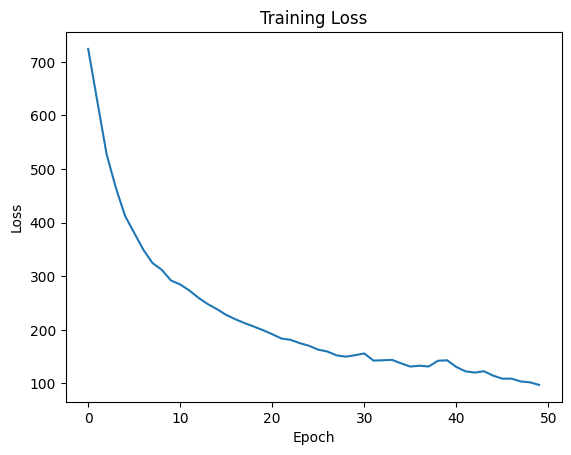

In [64]:
import matplotlib.pyplot as plt

plt.plot(epoch_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss")

plt.show()

In [66]:
total_params = sum(p.nelement() for p in model.parameters())
total_params

1142063